<a href="https://colab.research.google.com/github/fmuranda/Climate_Science./blob/main/PyQGIS_Workflow_for_LST_Calculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Conceptual PyQGIS Workflow for LST Calculation

This code is conceptual and demonstrates the *logic* using placeholder functions. In a real PyQGIS environment, you would use functions from `qgis.core` and `processing` modules to load rasters, perform raster calculations, and save outputs. For instance, `QgsRasterLayer` for loading and `QgsRasterCalculator` or `processing.run()` for calculations.

In [ ]:
# In a real PyQGIS environment, you would import these:
# from qgis.core import QgsRasterLayer, QgsRasterFileWriter, QgsRasterCalculator, QgsProject
# from qgis.analysis import QgsRasterCalculatorEntry
# import processing

import numpy as np
# For demonstration, we'll use placeholder functions and numpy to simulate raster operations.
# In a real PyQGIS script, these would be replaced by actual PyQGIS API calls.

def load_thermal_band_data(path):
    """Simulates loading a thermal band raster (e.g., Landsat Band 10/11 or Sentinel-2 equivalent)."""
    print(f"Simulating loading thermal band from: {path}")
    # In PyQGIS: layer = QgsRasterLayer(path, 'thermal_band')
    # if not layer.isValid(): raise Exception("Layer failed to load!")
    # data = layer.dataProvider().block(1, layer.extent(), layer.width(), layer.height()).data()

    # Dummy data for demonstration
    return np.random.rand(100, 100) * 20000 + 10000 # Simulate DN values (e.g., 10000-30000)

def calculate_radiance(dn_values, gain, offset):
    """Converts Digital Numbers (DN) to spectral radiance.
    For Landsat, gain and offset values are found in the MTL file.
    """
    print("Calculating radiance...")
    # In PyQGIS: Use QgsRasterCalculator or processing.run('qgis:rastercalculator', ...)
    return gain * dn_values + offset

def calculate_brightness_temperature(radiance, K1, K2):
    """Converts spectral radiance to at-sensor brightness temperature (in Kelvin).
    K1 and K2 are thermal conversion constants from the sensor metadata.
    """
    print("Calculating brightness temperature...")
    # In PyQGIS: Use QgsRasterCalculator or processing.run('qgis:rastercalculator', ...)
    return K2 / np.log((K1 / radiance) + 1)

def estimate_emissivity(ndvi_values, veg_threshold=0.5, soil_emissivity=0.97, veg_emissivity=0.99):
    """Estimates surface emissivity based on NDVI values.
    This is a simplified approach; more advanced methods exist.
    """
    print("Estimating emissivity...")
    # In PyQGIS: Use QgsRasterCalculator with conditional expressions.
    Pv = ((ndvi_values - 0.2) / (0.5 - 0.2))**2 # Proportion of vegetation
    Pv[ndvi_values < 0.2] = 0
    Pv[ndvi_values > 0.5] = 1

    emissivity = soil_emissivity * (1 - Pv) + veg_emissivity * Pv
    return emissivity

def calculate_lst(brightness_temperature, emissivity, wavelength=10.9e-6): # Wavelength in meters
    """Calculates Land Surface Temperature (LST) from brightness temperature and emissivity.
    This uses a simplified radiative transfer equation (e.g., mono-window algorithm concept).
    """
    print("Calculating LST...")
    # C2 is a constant related to Planck's law (h*c/k_b) in m*K
    C2_constant = 1.438 * 10**-2 # C2 constant in m*K

    # Ensure emissivity is within a valid range for np.log
    emissivity = np.clip(emissivity, 0.01, 0.9999)

    # Revised LST formula based on a common mono-window approximation:
    # LST = BT / (1 + (wavelength * BT / C2) * ln(emissivity))
    lst_kelvin = brightness_temperature / (1 + (wavelength * brightness_temperature / C2_constant) * np.log(emissivity))
    return lst_kelvin - 273.15 # Convert to Celsius

def save_raster_data(data, output_path, crs, extent, width, height):
    """Simulates saving the output raster data."""
    print(f"Simulating saving LST raster to: {output_path}")
    # In PyQGIS: Use QgsRasterFileWriter or processing.run('gdal:rasterize', ...)
    # writer = QgsRasterFileWriter(output_path)
    # writer.writeRaster(data, crs, extent, width, height)

# --- Workflow ---

# 1. Define Input Paths and Parameters (example for Landsat 8 Band 10)
thermal_band_path = "/path/to/your/thermal_band.tif" # Replace with actual path
ndvi_band_path = "/path/to/your/ndvi_band.tif"     # Replace with actual path
output_lst_path = "/path/to/output_lst.tif"       # Replace with actual output path

# Landsat 8 TIRS Band 10 specific constants (example values, get from MTL file)
GAIN = 3.3420 * 10**-4
OFFSET = 0.1
K1 = 774.8853
K2 = 1321.0789

# 2. Load Thermal Band DN and NDVI data
thermal_dn = load_thermal_band_data(thermal_band_path)
# For NDVI, you'd load a pre-calculated NDVI raster or calculate it from Red/NIR bands
# Dummy NDVI data for illustration
ndvi_data = np.random.rand(100, 100) * 0.8 + 0.1 # Simulate NDVI values (0.1-0.9)

# 3. Calculate Radiance
radiance = calculate_radiance(thermal_dn, GAIN, OFFSET)

# 4. Calculate Brightness Temperature (K)
bt_kelvin = calculate_brightness_temperature(radiance, K1, K2)

# 5. Estimate Emissivity
emissivity = estimate_emissivity(ndvi_data)

# 6. Calculate LST (Celsius)
lst_celsius = calculate_lst(bt_kelvin, emissivity)

print("LST Calculation Complete! First 5x5 LST values (Celsius):")
print(lst_celsius[:5, :5])

# 7. Save the LST raster
# In a real PyQGIS script, you would get CRS, extent, width, height from the input raster
# save_raster_data(lst_celsius, output_lst_path, crs, extent, width, height)

print(f"Conceptual LST values computed. In a real PyQGIS setup, the output would be saved to: {output_lst_path}")


Simulating loading thermal band from: /path/to/your/thermal_band.tif
Calculating radiance...
Calculating brightness temperature...
Estimating emissivity...
Calculating LST...
LST Calculation Complete! First 5x5 LST values (Celsius):
[[-25.19459617  31.56108491  -6.30321112  23.36078182  19.62467292]
 [ -2.14012764   4.71183364   2.90900872  29.73045641  24.90580327]
 [  0.92933918   9.29996122  -0.11366636 -15.33290782  26.98759432]
 [-12.70836527   3.03766939 -20.11217076  -9.01689722  -4.69122104]
 [ 15.94425159 -20.21125406  30.00033732   2.35379481   2.87698035]]
Conceptual LST values computed. In a real PyQGIS setup, the output would be saved to: /path/to/output_lst.tif


### Analyzing Computed LST Values

Minimum LST: -28.98 °C
Maximum LST: 32.62 °C
Mean LST: 4.87 °C
Standard Deviation of LST: 17.14 °C


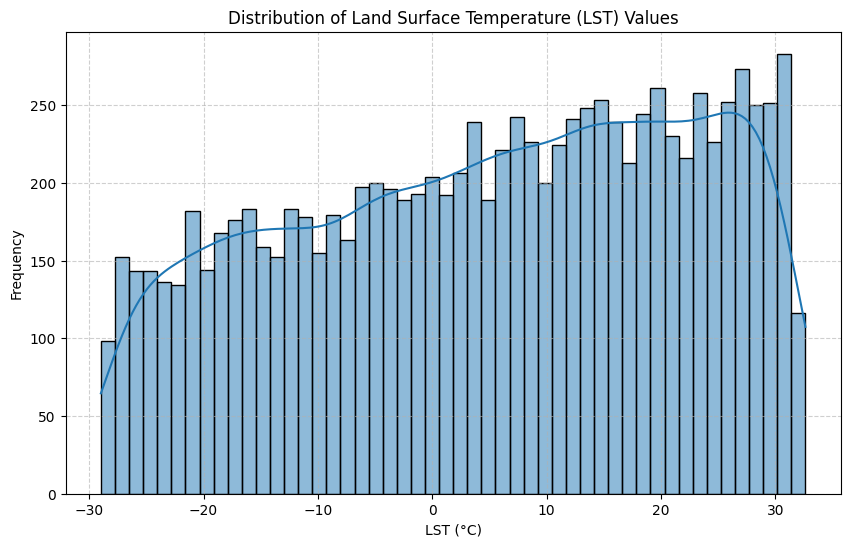

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic statistics of LST values
min_lst = np.min(lst_celsius)
max_lst = np.max(lst_celsius)
mean_lst = np.mean(lst_celsius)
std_lst = np.std(lst_celsius)

print(f"Minimum LST: {min_lst:.2f} °C")
print(f"Maximum LST: {max_lst:.2f} °C")
print(f"Mean LST: {mean_lst:.2f} °C")
print(f"Standard Deviation of LST: {std_lst:.2f} °C")

# Visualize the distribution of LST values
plt.figure(figsize=(10, 6))
sns.histplot(lst_celsius.flatten(), bins=50, kde=True)
plt.title('Distribution of Land Surface Temperature (LST) Values')
plt.xlabel('LST (°C)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()